# Olist: where should delivery improvement begin?
### B106 Data Visualisation (Mehran Monavari) · 
### Divakar Sabarwal GH1047352

### Github Link: 
https://github.com/sabarwaldivakar/Data-Visualisation-final-project 

## 1. Business context
Olist is a platform that connects small businesses with Brazilian marketplace customers. Its anonymised dataset records real 2016–2018 orders and reviews (Olist, 2021).

#### **Audience(Who):** Operations and Customer-experience managers.

#### **Problem(What):** With limited investigation capacity where to put attention first? Which periods, regions and delivery stages deserve more focus?

#### **Solution(How):** I connected delivery reliability with poor reviews, then narrowed the investigation. My analytical definition is that, Poor means **1–2 stars**. The aim is to prioritise audits, not prove causes or forecast savings.

## 2. Dataset and approach
[Olist dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Olist, 2021); CC BY-NC-SA 4.0. I will use orders, customers, reviews, items, products and category translations; payments, sellers and geolocation are outside scope. Sizes appear below.

The unit is **one order**. Items/reviews can have multiple rows per order; `customer_id` links location, not repeat customers. Milestones are dates, state/category categorical, and review score ordinal.


Run with CSV files under `data/`.

In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn
import streamlit

In [13]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
translation = pd.read_csv('data/product_category_name_translation.csv')

## 3. Exploring the data before cleaning
Here I imspected each table's size, duplicates and checked for the missing values, then inspected statuses, scores and numeric ranges. Repeated order IDs and missing review text need not to be errors because if a order have multiple items the order ID would appear multiple times in the items csv file, and review can sometimes only be numerical without an optional written comment.

In [14]:
tables = {'Orders': orders, 'Customers': customers, 'Reviews': reviews,
          'Items': items, 'Products': products, 'Translation': translation}
audit = []
for name, table in tables.items():
    audit.append([name, len(table), table.shape[1],
                  table.duplicated().sum(), table.isna().sum().sum()])
pd.DataFrame(audit, columns=['Table', 'Rows', 'Columns', 'Exact duplicates', 'Missing cells'])

,Table,Rows,Columns,Exact duplicates,Missing cells
0,Orders,99441,8,0,4908
1,Customers,99441,5,0,0
2,Reviews,99224,7,0,145903
3,Items,112650,7,0,0
4,Products,32951,9,0,2448
5,Translation,71,2,0,0


In [15]:
orders.info()
print('\nOrder status counts:\n', orders['order_status'].value_counts())
print('\nMissing order fields:\n', orders.isna().sum())
print('\nReview score counts:\n', reviews['review_score'].value_counts().sort_index())
print('\nRepeated review order IDs:', reviews['order_id'].duplicated().sum())
print('\nItem values:\n', items[['price', 'freight_value']].describe().round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Order status counts:
 order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Missing order fields:
 order_id

**Audit interpretation.** No exact duplicate rows occur. 
Reviews contain 551 repeated order IDs: keeping the latest response to avoid overweighting orders, check first responses later. Scores lie within 1–5. Left missing comments unfilled because comments couldn't be fillled with mean, median or any numeric values they had to be the words frim the customers; label 610 missing product categories and unmatched translations `Unknown`.

Missing delivery dates often reflect unfinished/cancelled orders; eight delivered orders also lack this date. Excluded them from delivery analysis. Item values have long upper tails but do not determine outcomes, which means that the most values are low but some values are a bit high but they do not affect the findings, so I did not remove them.

## 4. Prepare one row per order
Converted dates and used checked joins. **Late means after the promised calendar day**, not after midnight that day. Kept delivered orders with non-negative elapsed time and a positive promised duration. Excluded unreviewed orders only from review-rate denominators.

In [16]:
date_columns = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']
for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
latest_review = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='last')
df = orders.merge(customers[['customer_id', 'customer_state']],
                  on='customer_id', how='left', validate='one_to_one')
df = df.merge(latest_review[['order_id', 'review_score', 'review_answer_timestamp']],
              on='order_id', how='left', validate='one_to_one')
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['promise_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['late'] = df['order_delivered_customer_date'].dt.date > df['order_estimated_delivery_date'].dt.date
valid = (df['order_status'] == 'delivered') & df['delivery_days'].ge(0) & df['promise_days'].gt(0)
delivered = df.loc[valid].copy()
rated = delivered.dropna(subset=['review_score']).copy()
rated['poor_review'] = rated['review_score'].le(2)
print('All orders:', len(df), '| Valid delivered:', len(delivered), '| Rated:', len(rated))
print('Purchase range:', orders['order_purchase_timestamp'].min(), 'to', orders['order_purchase_timestamp'].max())
print('Unmatched customer states:', df['customer_state'].isna().sum())
delivered[['delivery_days', 'promise_days']].describe().round(2)

All orders: 99441 | Valid delivered: 96470 | Rated: 95824
Purchase range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Unmatched customer states: 0


,delivery_days,promise_days
count,96470.00,96470.00
mean,12.56,23.74
std,9.55,8.76
min,0.53,2.01
25%,6.77,18.33
50%,10.22,23.23
75%,15.72,28.41
max,209.63,155.14


**Interpretation:** There are **96,470 valid deliveries**, out of which **95,824** are **reviewed**. 6.77% of the deliveries are **delivered late**; 12.81% of the reviewed deliveries are **poor reviews**. The orders placed in the dataset are extended till october, but the delivered products data is only till august. So I did not compare the data which does not have a delivered data in this period to avoid the comparison of incomplete data. 

**Design:** All measures are **percentages**, normalised by relevant order counts or each order's duration. Dates/ratings are not rescaled. Bars start at zero; other ranges are explicit. Red shades, sparse labels and dark highlights limit clutter; box-plot hue distinguishes status.

In [24]:
seaborn.set(style='white', font_scale=1.05)
light_red = '#e8b4b0'
dark_red = '#9e1b32'

# Reuse the decluttering approach from the lecture examples.
def tidy_chart():
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

## 5. Five insights
### 5.1 Late deliveries receive more poor reviews—but timing matters
**Decision:** investigate reliability? Two bars compare poor-review percentages within status, avoiding domination by the larger on-time group.

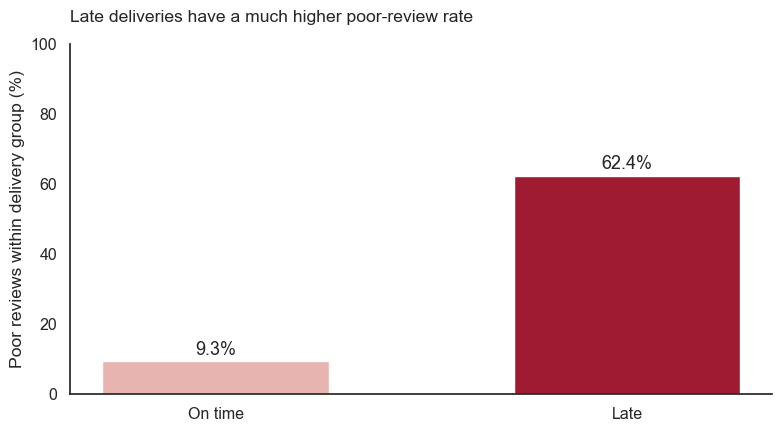

       orders  poor_pct
late                   
False   89443       9.3
True     6381      62.4
After-receipt review rates (%): {False: 9.3, True: 19.4}
After-receipt sample sizes: {False: 89263, True: 1908}
First-response rates (%): {False: 9.3, True: 62.4}


In [18]:
review_rates = rated.groupby('late').agg(orders=('order_id', 'count'),
                                          poor_pct=('poor_review', 'mean'))
review_rates['poor_pct'] = review_rates['poor_pct'] * 100
plt.figure(figsize=(8, 4.5))
plt.bar(['On time', 'Late'], review_rates['poor_pct'], color=[light_red, dark_red], width=0.55)
for x, value in enumerate(review_rates['poor_pct']):
    plt.text(x, value + 2, f'{value:.1f}%', ha='center', fontsize=13)
plt.ylim(0, 100)
plt.ylabel('Poor reviews within delivery group (%)')
plt.title('Late deliveries have a much higher poor-review rate', loc='left', pad=16)
tidy_chart()
plt.show()
print(review_rates.round(1))

# Sensitivity: reviews submitted after receipt, and first instead of latest responses.
after_receipt = rated.loc[rated['review_answer_timestamp'] >= rated['order_delivered_customer_date']]
print('After-receipt review rates (%):', (after_receipt.groupby('late')['poor_review'].mean() * 100).round(1).to_dict())
print('After-receipt sample sizes:', after_receipt.groupby('late').size().to_dict())
first_review = reviews.sort_values('review_answer_timestamp').drop_duplicates('order_id', keep='first')
first_check = delivered[['order_id', 'late']].merge(first_review[['order_id', 'review_score']], on='order_id', validate='one_to_one')
first_check['poor_review'] = first_check['review_score'].le(2)
print('First-response rates (%):', (first_check.groupby('late')['poor_review'].mean() * 100).round(1).to_dict())

**Interpretation:** 
poor-review rates are **62.4%** for **late** versus **9.3% on time**, the 53.2 percentage-point gap means the poor revies are mostly for the late reviews (6,381 and 89,443 orders). First-response rates are almost identical.

But **4,653 responses precede delivery**: Olist invites reviews after delivery or when the promised date is due (Olist, 2021). Among after-receipt responses, rates fall to **19.4% versus 9.3%** (1,908 and 89,263 orders). This changes the sample, not just timing; neither comparison estimates the cause. Poor reviews are considerably more common among late orders, so delivery reliability and communication deserve investigation. The dataset does not prove how much of the difference was caused by lateness itself.

Also, **67.5% of poor reviews concern on-time orders** (8,289/12,272), because that group is larger. Investigating late-order communication alongside product/service complaints is also necessary because fixing the lateness alone is not sufficient.

### 5.2 Late deliveries peaked in March,2018 which makes it worth investigating
**Decision:** which periods need an audit? A line chart shows late-delivery rates by purchase month. But the initial months were not considered becase of the low number of orders and the final August 2018 cohort was also not considered due to incomplete information.

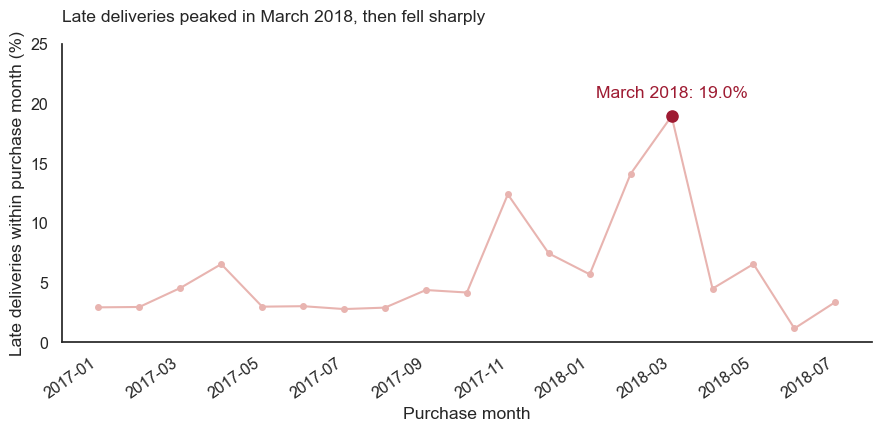

Monthly sample sizes: 750 to 7288
         orders  late_pct
month                    
2017-11    7288      12.4
2018-03    7003      19.0
2018-04    6798       4.5


In [25]:
delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly = delivered.groupby('month').agg(orders=('order_id', 'count'), late_pct=('late', 'mean'))
monthly['late_pct'] = monthly['late_pct'] * 100
monthly = monthly.loc['2017-01':'2018-07']
plt.figure(figsize=(9, 4.5))
plt.plot(monthly.index, monthly['late_pct'], color=light_red, marker='o', markersize=4)
plt.scatter('2018-03', monthly.loc['2018-03', 'late_pct'], color=dark_red, s=65, zorder=3)
plt.text(14, 20.5, 'March 2018: 19.0%', color=dark_red, ha='center')
plt.xticks(range(0, len(monthly), 2), monthly.index[::2], rotation=35, ha='right')
plt.ylim(0, 25)
plt.ylabel('Late deliveries within purchase month (%)')
plt.xlabel('Purchase month')
plt.title('Late deliveries peaked in March 2018, then fell sharply', loc='left', pad=16)
tidy_chart()
plt.show()
print('Monthly sample sizes:', monthly['orders'].min(), 'to', monthly['orders'].max())
print(monthly.loc[['2017-11', '2018-03', '2018-04']].round(1))

**Interpretation:** In March the late delivery rate reached **19.0%** (7,003 orders), compared to that from April's **4.5%** (6,798). November 2017 had more orders (7,288) but only 12.4% reached late. Volume alone does not explain the peak. All plotted cohorts have at least 750 orders.

The first tasks to do would be the inspectipon of February–March staffing, dispatch and transport records. These all are purchase cohorts, not delivery months. Unresolved orders are excluded but they also need to be taken care on the side. The short history cannot establish seasonality or causes.

### 5.3 Rio combines high dissatisfaction with substantial volume
**Decision:** Now comes the point where we have to decied, that where should we start the investigation? 

Each scatter point is a state. The rate used is reviewed orders. It requires 500 observations to reduce small-group instability. I labelled key comparisons only between the bigger cities and where the rate of late deliveries was more.

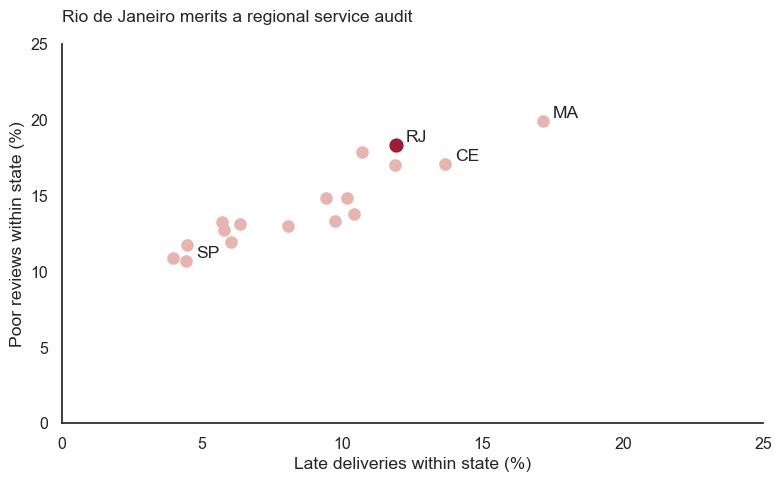

States shown: 17 | Rated orders covered (%): 97.4
                orders  late_pct  poor_pct
customer_state                            
RJ               12211      11.9      18.3
SP               40266       4.4      10.7
MA                 712      17.1      19.9
CE                1273      13.7      17.1


In [26]:
states = rated.groupby('customer_state').agg(orders=('order_id', 'count'),
                 late_pct=('late', 'mean'), poor_pct=('poor_review', 'mean'))
states[['late_pct', 'poor_pct']] = states[['late_pct', 'poor_pct']] * 100
state_view = states.loc[states['orders'] >= 500]
plt.figure(figsize=(8, 5))
plt.scatter(state_view['late_pct'], state_view['poor_pct'], color=light_red, s=65)
plt.scatter(states.loc['RJ', 'late_pct'], states.loc['RJ', 'poor_pct'], color=dark_red, s=85)
for state in ['RJ', 'SP', 'MA', 'CE']:
    plt.text(states.loc[state, 'late_pct'] + 0.35, states.loc[state, 'poor_pct'] + 0.2, state)
plt.xlim(0, 25)
plt.ylim(0, 25)
plt.xlabel('Late deliveries within state (%)')
plt.ylabel('Poor reviews within state (%)')
plt.title('Rio de Janeiro merits a regional service audit', loc='left', pad=16)
tidy_chart()
plt.show()
print('States shown:', len(state_view), '| Rated orders covered (%):', round(state_view['orders'].sum() / len(rated) * 100, 1))
print(states.loc[['RJ', 'SP', 'MA', 'CE']].round(1))

**Observation:** Rio de Janeiro (RJ) has **12,211 orders**, 11.9% late and 18.3% poor reviews, São Paulo (SP) has 40,266 orders, out of which 4.4% are late and 10.7% are poorly reviewed. Maranhão (MA) and Ceará (CE) also need attention looking ate the rates but the number of orders is also less for these two 712 and 1,273 respectively.

RJ combines scale and rates; SP still has more complaints. Product mix, sellers, promises or purchase periods may explain the association. Next, I will check categories without claiming causation.

### 5.4 Rio's pattern persists across major product categories
**Decision:** Now we know that where the problem is but the next question is that is it a single-product problem or multi-product problem? To check that I joinec items to categories; retained one row per single-category order. Selected the five largest states/categories by volume. 

A heatmap is made here to avoid crowded grouped bars.

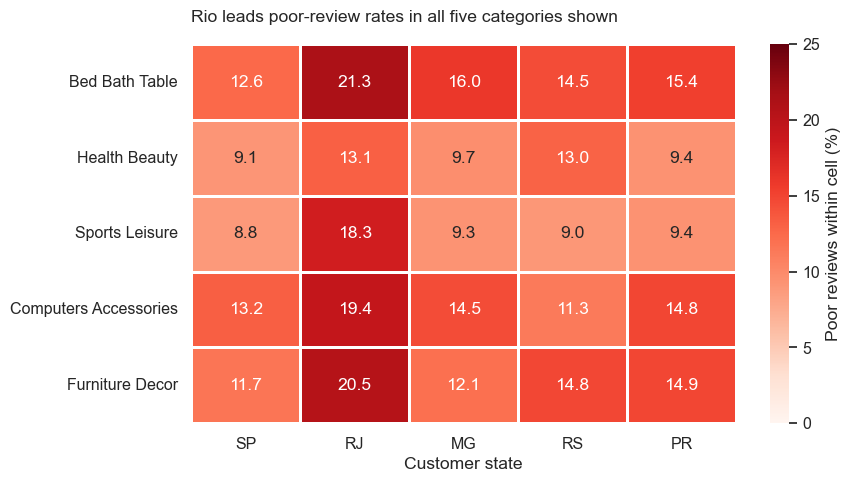

Single-category rated orders: 95050 | Excluded: 774
Orders per displayed cell: 330 to 4222
Displayed orders: 29331


In [33]:
item_cats = items.merge(products[['product_id', 'product_category_name']],
                              on='product_id', how='left', validate='many_to_one')
item_cats = item_cats.merge(translation, on='product_category_name', how='left', validate='many_to_one')
item_cats['category'] = item_cats['product_category_name_english'].fillna('Unknown')
category_counts = item_cats.groupby('order_id')['category'].nunique()
single_ids = category_counts.loc[category_counts == 1].index
single_category = item_cats.loc[item_cats['order_id'].isin(single_ids), ['order_id', 'category']].drop_duplicates()
category_orders = rated.merge(single_category, on='order_id', validate='one_to_one')
top_states = category_orders['customer_state'].value_counts().head(5).index
top_categories = category_orders['category'].value_counts().head(5).index
selected = category_orders.loc[category_orders['customer_state'].isin(top_states) & category_orders['category'].isin(top_categories)]
category_rates = selected.groupby(['category', 'customer_state'], as_index=False).agg(
    orders=('order_id', 'count'), poor_pct=('poor_review', 'mean'))
category_rates['poor_pct'] = category_rates['poor_pct'] * 100
heat = category_rates.pivot(index='category', columns='customer_state', values='poor_pct').loc[top_categories, top_states]
heat.index = heat.index.str.replace('_', ' ').str.title()
plt.figure(figsize=(9, 5))
seaborn.heatmap(heat, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=25,
                linewidths=1, cbar_kws={'label': 'Poor reviews within cell (%)'})
plt.title('Rio leads poor-review rates in all five categories shown', loc='left', pad=16)
plt.xlabel('Customer state')
plt.ylabel('')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print('Single-category rated orders:', len(category_orders), '| Excluded:', len(rated) - len(category_orders))
print('Orders per displayed cell:', category_rates['orders'].min(), 'to', category_rates['orders'].max())
print('Displayed orders:', len(selected))

**Interpretation:** RJ has late deliveries for every displayed category among these states. Bed_bath_table is **21.3% versus SP's 12.6%**, sports/leisure 18.3% versus 8.8%. Investigation requires to look for shared regional processes rather than a single-category explanation.

1 Cell has 330–4,222 orders, separate denominators and a common colour scale. Exclude 774 mixed-category reviewed orders and smaller groups. Time, seller and review timing remain uncontrolled: this is a consistency check, not causal adjustment.

### 5.5 Late orders spend more delivery time after handoff
**Decision:** Now comes the main decision where exactly are the delays happening? Is it on our end? Is it on the delivery partners end? To check that I split duration at carrier handoff, validate chronology and divide stages by total order duration. A box plot with status hue is used to compare the distribution.

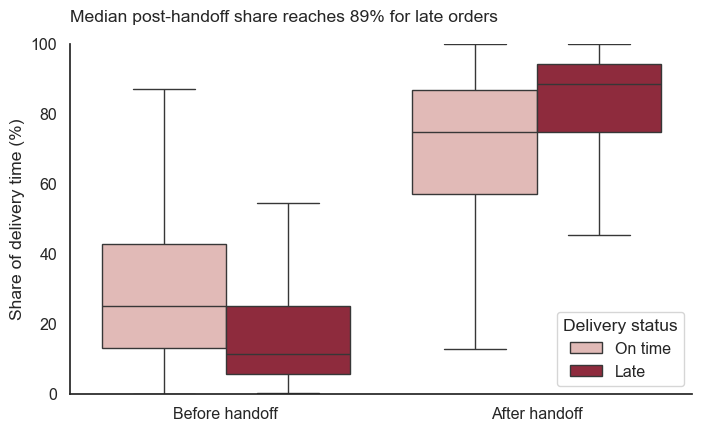

Valid stage records: 96281 | Excluded: 189
                 before_days  after_days  Before handoff  After handoff
Delivery status                                                        
Late                     3.5        26.2            11.4           88.6
On time                  2.2         6.9            25.0           75.0
Stage sample sizes: {'On time': 89750, 'Late': 6531}


In [34]:
delivered['before_days'] = (delivered['order_delivered_carrier_date'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered['after_days'] = (delivered['order_delivered_customer_date'] - delivered['order_delivered_carrier_date']).dt.total_seconds() / 86400
stages = delivered.loc[delivered['before_days'].ge(0) & delivered['after_days'].ge(0) & delivered['delivery_days'].gt(0)].copy()
stages['Before handoff'] = 100 * stages['before_days'] / stages['delivery_days']
stages['After handoff'] = 100 * stages['after_days'] / stages['delivery_days']
stages['Delivery status'] = np.where(stages['late'], 'Late', 'On time')
stage_long = stages.melt(id_vars=['Delivery status'], value_vars=['Before handoff', 'After handoff'],
                        var_name='Stage', value_name='Share of delivery time (%)')
g = seaborn.catplot(data=stage_long, x='Stage', y='Share of delivery time (%)',
    hue='Delivery status', hue_order=['On time', 'Late'], kind='box',
    palette=[light_red, dark_red], showfliers=False, height=4.5, aspect=1.6, legend_out=False)
g.set(ylim=(0, 100))
plt.title('Median post-handoff share reaches 89% for late orders', loc='left', pad=16)
plt.xlabel('')
tidy_chart()
plt.show()
print('Valid stage records:', len(stages), '| Excluded:', len(delivered) - len(stages))
print(stages.groupby('Delivery status')[['before_days', 'after_days', 'Before handoff', 'After handoff']].median().round(1))
print('Stage sample sizes:', stages['Delivery status'].value_counts().to_dict())

**Interpretation:** Median of after-handoff delays are **88.6% late versus 75.0% on time**. Median after-handoff durations are 26.2 days versus 6.9 days. Before-handoff durations are 3.5 days versus 2.2 days. Inspection of after-handoff events should be the priority. But a smaller before-handoff share does not mean a shorter stage, its just the overall delay is more after-handoff. Once that is fixed we will have to look for the problems in before handoff delays as well.


## 6. Recommendations and critical evaluation
1. **Operations: Investigate RJ journeys across major categories**, alongside February–March incident records. High rates, substantial volume and the cross-category pattern justify investigating dispatch and delivery events.
2. **Customer experience: Inspect post-handoff delays and late-order communication.** Track lateness and poor-review percentages separately with stable denominators and review timing. The full 53-point review gap is not a causal effect.
3. **Investigate on-time complaints in parallel**, particularly high-volume SP: these form 67.5% of poor reviews. Read comments to distinguish product, seller and delivery issues; the text has not been classified in this notebook only the numeric values are being investigated.

**Strengths:** Checked order-level joins, explicit denominators, selective cleaning and review-choice/timing sensitivity checks. 

**Limitations:** So, there are a lot of things missing here. Like, if you only look at what’s delivered or reviewed, you just miss out on all the stuff that’s not sorted yet or nobody has checked. Sometimes the reviews are even older than when you actually get the thing. And if you pick by category or state, you just ignore the smaller groups completely. Then there’s the whole thing with sellers acting differently, or the products changing, or people buying at different times, so you can’t really compare properly. There’s no way to see how sure you are about anything, and nothing is adjusted for all these things happening at once. Old data doesn’t really tell you what’s going on now, so you can’t just use it for budgets or rankings or whatever savings you think you’ll get.

## Conclusion:
Begin with RJ and post-handoff events while retaining an on-time-complaint investigation. These would be the first steps but later we will have to look for other states and pre-handoff problems as well. Together working on all the problems the company can grow and work better on the customer satisfaction. 

## 7. References
Olist (2021) *Brazilian E-Commerce Public Dataset by Olist* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce .

Monavari M. and Mahdavi M. **Lecture Slides** uploaded on Canvas, Gisma University of Applied Sciences.